In [41]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import rioxarray

<font color='red'>1.0. Login to GitHub and join our pacific-coding-community:
- https://github.com/pacific-coding-community
- https://github.com/Maivunijale/fiji-lulc-workshop-2026
- https://github.com/digitalearthpacific

And optionally connect and follow for more updates and learning materials: 
- https://github.com/Maivunijale
- https://github.com/elenoab99
- https://github.com/nicholasmetherall

In [95]:
#Data 1
input1 = "mw-lulc-macuata-prediction_2025.tiff"   # <-- change this
output1 = "2025_lulc_macuata_class_2.tiff"
#Data 2
input2 = "mw-lulc-macuata-prediction_2024.tiff"
output2 = "2024_lulc_macuata_class_2.tiff"

### Comment

### LULC Processing and Visualizaion

In [96]:
TARGET_CLASS = 2

In [97]:
# -------------------------
# Load rasters
# -------------------------
with rasterio.open(input1) as src1:
    lulc_2025 = src1.read(1)
    profile_2025 = src1.profile

with rasterio.open(input2) as src2:
    lulc_2024 = src2.read(1)
    profile_2024 = src2.profile

print("2024 shape:", lulc_2024.shape)
print("2025 shape:", lulc_2025.shape)

2024 shape: (1135, 1227)
2025 shape: (1135, 1227)


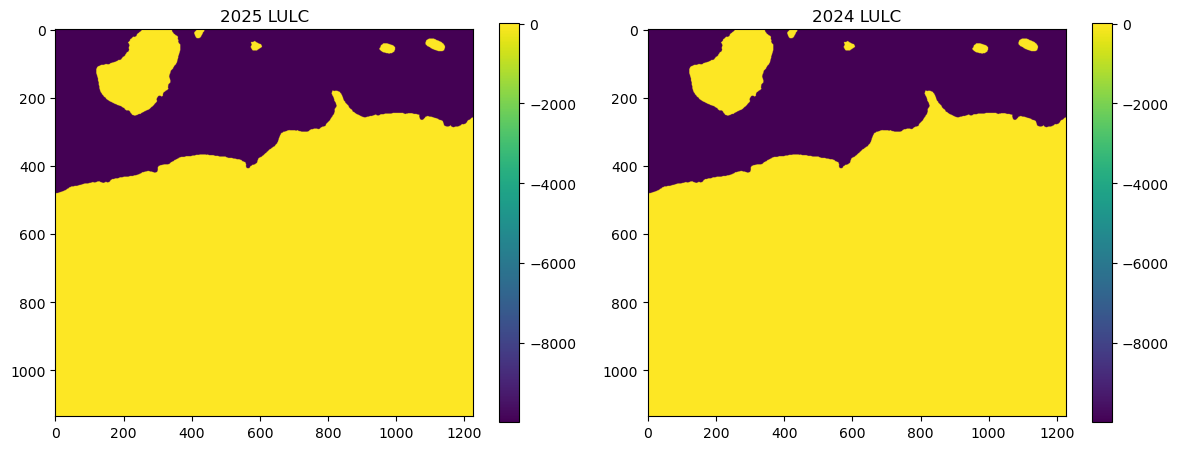

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# 2025
im1 = axes[0].imshow(lulc_2025)
axes[0].set_title("2025 LULC")

# 2024
im2 = axes[1].imshow(lulc_2024)
axes[1].set_title("2024 LULC")

plt.colorbar(im1, ax=axes[0], shrink=0.7)
plt.colorbar(im2, ax=axes[1], shrink=0.7)

plt.tight_layout()
#plt.show()
plt.imshow(lulc_2025, cmap="viridis")

### Class Extraction

In [99]:
# lulc = [lulc_2024, lulc_2025]

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio

# -------------------------
# Load 2024 raster
# -------------------------
with rasterio.open(input2) as src:
    lulc_2024 = src.read(1)

# Extract target class
extracted_2024 = np.where(lulc_2024 == TARGET_CLASS, 1, 0)


# -------------------------
# Load 2025 raster
# -------------------------
with rasterio.open(input1) as src:
    lulc_2025 = src.read(1)

# Extract target class
extracted_2025 = np.where(lulc_2025 == TARGET_CLASS, 1, 0)

In [101]:
# -------------------------
# 2024 processing + export
# -------------------------
with rasterio.open(input2) as src:
    lulc_2024 = src.read(1)
    profile_2024 = src.profile  # keep metadata

extracted_2024 = np.where(lulc_2024 == TARGET_CLASS, 1, 0).astype(rasterio.uint8)

profile_2024.update(
    dtype=rasterio.uint8,
    count=1,
    compress='lzw'
)

output_2024 = (f"2024_lulc_macuata_class_{TARGET_CLASS}.tif")

with rasterio.open(output_2024, "w", **profile_2024) as dst:
    dst.write(extracted_2024, 1)


# -------------------------
# 2025 processing + export
# -------------------------
with rasterio.open(input1) as src:
    lulc_2025 = src.read(1)
    profile_2025 = src.profile

extracted_2025 = np.where(lulc_2025 == TARGET_CLASS, 1, 0).astype(rasterio.uint8)

profile_2025.update(
    dtype=rasterio.uint8,
    count=1,
    compress='lzw'
)

output_2025 = (f"2025_lulc_macuata_class_{TARGET_CLASS}.tif")

with rasterio.open(output_2025, "w", **profile_2025) as dst:
    dst.write(extracted_2025, 1)

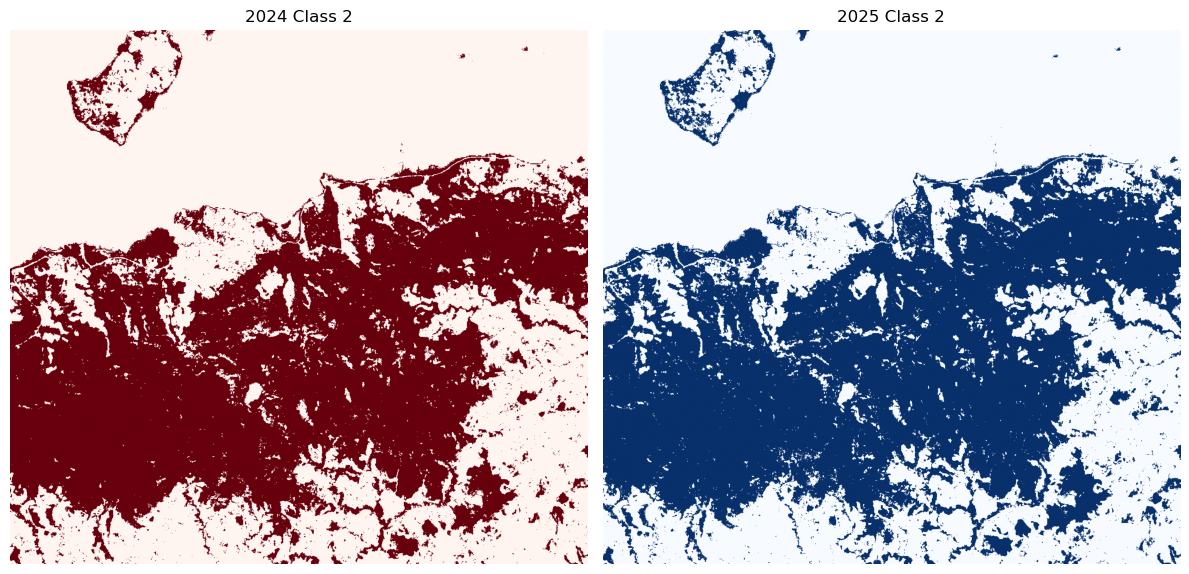

In [102]:
# -------------------------
# Side-by-side visualization
# -------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# 2024
ax[0].imshow(extracted_2024, cmap="Reds")
ax[0].set_title(f"2024 Class {TARGET_CLASS}")
ax[0].axis("off")

# 2025
ax[1].imshow(extracted_2025, cmap="Blues")
ax[1].set_title(f"2025 Class {TARGET_CLASS}")
ax[1].axis("off")

plt.tight_layout()
plt.show()

Unique change values: [-1  0  1]


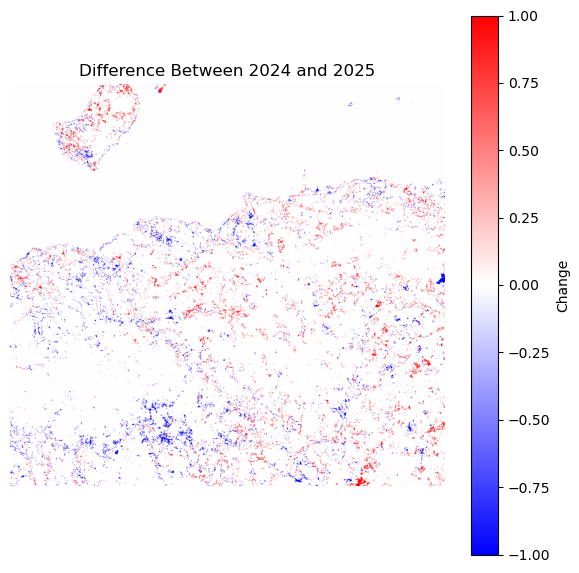

In [103]:
import rasterio

# Reload profile from 2024 raster
with rasterio.open(input2) as src:
    profile_2024 = src.profile

#-------------------------
# Calculate Difference
# -------------------------
# 2025 - 2024
change = extracted_2025.astype("int8") - extracted_2024.astype("int8")

# Values:
# -1 = Loss
#  0 = No Change
#  1 = Gain

print("Unique change values:", np.unique(change))


# -------------------------
# Visualize Difference Layer
# -------------------------
plt.figure(figsize=(7,7))

plt.title("Difference Between 2024 and 2025")

img = plt.imshow(change, cmap="bwr", vmin=-1, vmax=1)

cbar = plt.colorbar(img)
cbar.set_label("Change")

plt.axis("off")
plt.show()

In [104]:
# -------------------------
# Export Difference Raster
# -------------------------
output_change = "difference_2024_2025.tiff"

# Use metadata from original raster
profile_2024.update(
    dtype="int8",
    count=1,
    compress="lzw"
)

with rasterio.open(output_change, "w", **profile_2024) as dst:
    dst.write(change.astype("int8"), 1)

print(f"Saved: {output_change}")

Saved: difference_2024_2025.tiff


#### AREA CALCULATION

In [107]:
import rasterio
import numpy as np

#output1 = ("2024_lulc_macuata_class_2.tif")
#output2 = ("2025_lulc_macuata_class_2.tif")

# -------------------------
# Load extracted rasters
# -------------------------
with rasterio.open(output_2024) as src:
    extracted_2024 = src.read(1)
    transform = src.transform
    crs = src.crs

with rasterio.open(output_2025) as src:
    extracted_2025 = src.read(1)

# -------------------------
# Change detection
# -------------------------
change = extracted_2025.astype("int8") - extracted_2024.astype("int8")

# -------------------------
# Pixel area calculation
# -------------------------
# Pixel size from affine transform
pixel_width = abs(transform.a)
pixel_height = abs(transform.e)

# Area per pixel in square meters
pixel_area_sqm = pixel_width * pixel_height

print("Pixel area (sqm):", pixel_area_sqm)

# -------------------------
# Count pixels
# -------------------------
pixels_2024 = np.sum(extracted_cl_2024 == 1)
pixels_2025 = np.sum(extracted_cl_2025 == 1)

gain_pixels = np.sum(change == 1)
loss_pixels = np.sum(change == -1)

# -------------------------
# Area calculations
# -------------------------
def calculate_areas(pixel_count, pixel_area):
    sqm = pixel_count * pixel_area
    ha = sqm / 10000
    sqkm = sqm / 1_000_000
    acres = sqm / 4046.85642

    return sqm, ha, sqkm, acres

# 2024
sqm_2024, ha_2024, sqkm_2024, acres_2024 = calculate_areas(
    pixels_2024,
    pixel_area_sqm
)

# 2025
sqm_2025, ha_2025, sqkm_2025, acres_2025 = calculate_areas(
    pixels_2025,
    pixel_area_sqm
)

# Gain
sqm_gain, ha_gain, sqkm_gain, acres_gain = calculate_areas(
    gain_pixels,
    pixel_area_sqm
)

# Loss
sqm_loss, ha_loss, sqkm_loss, acres_loss = calculate_areas(
    loss_pixels,
    pixel_area_sqm
)

# -------------------------
# Print Results
# -------------------------
print("\n===== 2024 Area =====")
print(f"sqm   : {sqm_2024:,.2f}")
print(f"ha    : {ha_2024:,.2f}")
print(f"sqkm  : {sqkm_2024:,.4f}")
print(f"acres : {acres_2024:,.2f}")

print("\n===== 2025 Area =====")
print(f"sqm   : {sqm_2025:,.2f}")
print(f"ha    : {ha_2025:,.2f}")
print(f"sqkm  : {sqkm_2025:,.4f}")
print(f"acres : {acres_2025:,.2f}")

print("\n===== Gain Area =====")
print(f"sqm   : {sqm_gain:,.2f}")
print(f"ha    : {ha_gain:,.2f}")
print(f"sqkm  : {sqkm_gain:,.4f}")
print(f"acres : {acres_gain:,.2f}")

print("\n===== Loss Area =====")
print(f"sqm   : {sqm_loss:,.2f}")
print(f"ha    : {ha_loss:,.2f}")
print(f"sqkm  : {sqkm_loss:,.4f}")
print(f"acres : {acres_loss:,.2f}")

Pixel area (sqm): 100.0

===== 2024 Area =====
sqm   : 0.00
ha    : 0.00
sqkm  : 0.0000
acres : 0.00

===== 2025 Area =====
sqm   : 0.00
ha    : 0.00
sqkm  : 0.0000
acres : 0.00

===== Gain Area =====
sqm   : 2,609,300.00
ha    : 260.93
sqkm  : 2.6093
acres : 644.77

===== Loss Area =====
sqm   : 2,537,200.00
ha    : 253.72
sqkm  : 2.5372
acres : 626.96
